In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage

In [2]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [3]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


In [4]:
def convert_to_greyscale(img):
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Display output image
    plt.figure(figsize=(6,6))
    plt.imshow(grey, cmap='gray')
    plt.title("Greyscale Output")
    plt.axis('off')

    return grey

In [5]:
def enhance_contrast(img):
    """
    Linear contrast stretching using 2nd–98th percentiles.
    Works well on aerial parking images.
    Accepts grayscale or BGR numpy arrays.
    """

    # If it's color (BGR), convert to YCrCb for luminance-only stretching
    if len(img.shape) == 3:
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        y = ycrcb[:, :, 0]

        # Percentile-based contrast stretch
        p2, p98 = np.percentile(y, (2, 98))
        y_stretched = np.clip((y - p2) * 255.0 / (p98 - p2), 0, 255).astype(np.uint8)

        ycrcb[:, :, 0] = y_stretched
        out = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    else:  # greyscale
        p2, p98 = np.percentile(img, (2, 98))
        out = np.clip((img - p2) * 255.0 / (p98 - p2), 0, 255).astype(np.uint8)

    # Display result
    plt.figure(figsize=(6,6))
    if len(out.shape) == 2:
        plt.imshow(out, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title("Contrast Enhanced")
    plt.axis("off")

    return out

In [6]:
def blur_image(img, method="gaussian", k=9):
    """
    Blur the image to reduce noise before edge detection.
    method: "gaussian" (default) or "median" or "bilateral"
    k: kernel size (must be odd)
    
    Accepts grayscale or BGR numpy arrays.
    """

    # --- Gaussian Blur (recommended for this project) ---
    if method == "gaussian":
        blurred = cv2.GaussianBlur(img, (k, k), sigmaX=0)

    # --- Median Blur (robust to speckle + shadows) ---
    elif method == "median":
        blurred = cv2.medianBlur(img, k)

    # --- Bilateral (best detail preservation, slow) ---
    elif method == "bilateral":
        blurred = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    else:
        raise ValueError("Unknown blur method")

    # Display
    plt.figure(figsize=(6,6))
    if len(blurred.shape) == 2:
        plt.imshow(blurred, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    plt.title(f"Blurred ({method})")
    plt.axis("off")

    return blurred

In [7]:
def edge_detection(img, use_automatic=True, low=50, high=150):
    """
    Perform Canny edge detection.
    
    If use_automatic=True:
        Automatically computes thresholds based on image statistics.
    Otherwise:
        Uses manual low/high thresholds.
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    # --- Automatic thresholding (recommended) ---
    if use_automatic:
        # Compute Otsu threshold
        otsu_thresh, _ = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Canny thresholds relative to Otsu value
        low_t  = max(5, 0.5 * otsu_thresh)
        high_t = min(255, 1.5 * otsu_thresh)
    else:
        low_t, high_t = low, high

    edges = cv2.Canny(img_gray, int(low_t), int(high_t))

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(edges, cmap='gray')
    plt.title(f"Canny Edges (low={int(low_t)}, high={int(high_t)})")
    plt.axis("off")

    return edges


In [8]:
def compute_gradients(img):
    """
    Compute Sobel gradients in X and Y directions.
    Returns (gx, gy, magnitude, direction).
    Accepts grayscale or BGR numpy arrays.
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # Sobel gradients
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    # Magnitude + direction
    mag = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)  # radians

    # Normalize magnitude for display
    mag_disp = (mag / mag.max() * 255).astype(np.uint8)

    # Display (magnitude only)
    plt.figure(figsize=(6,6))
    plt.imshow(mag_disp, cmap='gray')
    plt.title("Gradient Magnitude")
    plt.axis("off")

    return gx, gy, mag, direction


In [9]:
def edge_enhancement(img_gradients, original_img, alpha=0.7, mag_thresh=40):
    """
    Enhance only strong edges by thresholding gradient magnitude.

    img_gradients: (gx, gy, mag, direction)
    original_img: grayscale or BGR input
    alpha: strength of sharpening
    mag_thresh: minimum gradient magnitude to keep a pixel as an edge
    """

    gx, gy, mag, direction = img_gradients

    # Convert input image to grayscale
    if len(original_img.shape) == 3:
        gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = original_img

    # --- Gradient magnitude threshold ---
    edge_mask = (mag > mag_thresh).astype(np.uint8)

    # Normalize magnitude to 0–255
    mag_norm = np.uint8(255 * (mag / (mag.max() + 1e-6)))

    # Keep *only* strong gradient areas
    mag_filtered = cv2.bitwise_and(mag_norm, mag_norm, mask=edge_mask)

    # Add filtered edges back to the image
    sharpened = gray.astype(np.float32) + alpha * mag_filtered.astype(np.float32)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    # Visualize for debugging
    plt.figure(figsize=(6,6))
    plt.imshow(sharpened, cmap="gray")
    plt.title(f"Edge Enhanced (alpha={alpha}, mag_thresh={mag_thresh})")
    plt.axis("off")

    return sharpened

In [10]:
def mask_or_binarise(img):
    """
    Produce a clean binary mask from a sharpened grayscale image.
    Uses adaptive thresholding + morphological cleanup.
    Input: grayscale or sharpened grayscale image.
    Output: binary mask (0/255)
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # --- Adaptive binarisation ---
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31,       # adaptive window size
        C=5                 # constant subtraction
    )

    # --- Clean mask ---
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Show result
    plt.figure(figsize=(6,6))
    plt.imshow(binary, cmap="gray")
    plt.title("Binary Mask / Threshold Output")
    plt.axis("off")

    return binary

In [68]:
def erode(mask):

    h, w = mask.shape
    img_diag = int(np.sqrt(h*h + w*w))
    
    if img_diag < 800:
        ksize = 3
        iterations = 1
    elif img_diag < 1500:
        ksize = 5
        iterations = 2
    elif img_diag < 2500:
        ksize = 7
        iterations = 2
    else:
        ksize = 11
        iterations = 2
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    eroded = cv2.erode(mask, kernel, iterations)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(eroded, cmap="gray")
    plt.title(f"Erosion (ksize={ksize})")
    plt.axis("off")

    return eroded

In [48]:
def skeletonize_lines(mask):
    # mask = 0/255
    binary = (mask > 0).astype(np.uint8)
    skel = skeletonize(binary).astype(np.uint8) * 255

    plt.figure(figsize=(6,6))
    plt.imshow(skel, cmap="gray")
    plt.title("Skeletonized Lines")
    plt.axis("off")
    
    return skel

In [49]:
def thicken_lines(mask, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    thick = cv2.dilate(mask, kernel, iterations=1)
    #smoothed = cv2.GaussianBlur(thick, (9,9), 0)
    plt.figure(figsize=(6,6))
    plt.imshow(thick, cmap="gray")
    plt.title("Thickened Lines + Smoothed")
    plt.axis("off")
    
    return thick

In [50]:
def detect_hough_lines(mask, rho=1, theta=np.pi/180, threshold=100):
    """
    Detects infinite Hough lines (not segments) from a binary mask.
    Returns a list of (rho, theta) pairs.
    """

    # Hough expects edges or thin bright strokes → thick_lines is perfect
    lines = cv2.HoughLines(mask, rho, theta, threshold)

    # Display visualization
    vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    if lines is not None:
        for line in lines:
            rho, theta = line[0]

            # convert polar -> line endpoints for drawing
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            # two far-away points
            x1 = int(x0 + 2000 * (-b))
            y1 = int(y0 + 2000 * (a))
            x2 = int(x0 - 2000 * (-b))
            y2 = int(y0 - 2000 * (a))

            cv2.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Standard Hough Lines (Infinite Lines)")
    plt.axis("off")

    return lines

In [51]:
def hough_lines_to_mask(lines, shape, thickness=2, horizontal_thresh=np.deg2rad(5)):
    """
    Converts infinite Hough lines (rho, theta) into binary masks.
    
    Returns:
        non_horizontal_mask  - mask with ONLY non-horizontal lines
        horizontal_mask      - mask with ONLY horizontal lines
    """

    h, w = shape
    non_horizontal = np.zeros((h, w), dtype=np.uint8)
    horizontal = np.zeros((h, w), dtype=np.uint8)

    if lines is None:
        return non_horizontal, horizontal

    for line in lines:
        rho, theta = line[0]

        # Horizontal line check: theta ≈ 90° (pi/2)
        is_horizontal = abs(theta - np.pi/2) < horizontal_thresh

        # Precompute line endpoints
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 2000 * (-b))
        y1 = int(y0 + 2000 * (a))
        x2 = int(x0 - 2000 * (-b))
        y2 = int(y0 - 2000 * (a))

        if is_horizontal:
            cv2.line(horizontal, (x1, y1), (x2, y2), 255, thickness+10)
        else:
            cv2.line(non_horizontal, (x1, y1), (x2, y2), 255, thickness)

    return non_horizontal, horizontal


In [52]:
def intersect_hough_with_mask(hough_mask, thick_lines):
    """
    Keep only pixels where both the thick line mask and Hough lines overlap.
    This trims infinite lines down to actual parking lines.
    """

    # binary AND
    intersection = cv2.bitwise_and(hough_mask, thick_lines)

    plt.figure(figsize=(6,6))
    plt.imshow(intersection, cmap="gray")
    plt.title("Finite Parking Lines (Hough ∩ ThickLines)")
    plt.axis("off")

    return intersection

In [53]:
def remove_horizontal_from_finite(finite_lines, horizontal_mask):
    """
    Removes horizontal-line pixels from the finite_lines mask.

    Args:
        finite_lines      - mask of vertical/diagonal finite line pixels (0/255)
        horizontal_mask   - mask containing ONLY horizontal Hough lines (0/255)

    Returns:
        cleaned_mask      - finite_lines with horizontal influence removed
    """

    # Ensure both are uint8 and binary
    f = (finite_lines > 0).astype(np.uint8) * 255
    h = (horizontal_mask > 0).astype(np.uint8) * 255

    # Subtract horizontal mask
    cleaned = cv2.bitwise_and(f, cv2.bitwise_not(h))

    # Display result
    plt.figure(figsize=(6,6))
    plt.imshow(cleaned, cmap="gray")
    plt.title("Finite Lines With Horizontal Removed")
    plt.axis("off")

    return cleaned

In [54]:
def detect_parking_segments(thick_lines_mask,
                            threshold=10,
                            min_line_length=30,
                            max_line_gap=10,
                            theta_resolution=0.5,
                            upscale_factor=3):
    """
    Runs HoughLinesP on the processed thick line mask to detect
    finite line segments representing parking-space dividers.
    """
    # Upscale the mask to increase resolution
    if upscale_factor > 1:
        h, w = thick_lines_mask.shape[:2]
        upscaled_mask = cv2.resize(
            thick_lines_mask, 
            (w * upscale_factor, h * upscale_factor),
            interpolation=cv2.INTER_LINEAR  # or INTER_CUBIC for smoother lines
        )
        
        # Re-threshold after interpolation to ensure binary
        _, upscaled_mask = cv2.threshold(upscaled_mask, 127, 255, cv2.THRESH_BINARY)
    else:
        upscaled_mask = thick_lines_mask
    
    lines = cv2.HoughLinesP(
        thick_lines_mask,
        rho=1,
        theta=np.pi/(180/theta_resolution),
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )
    
    return lines

In [55]:
def draw_detected_line_segments(lines, mask):
    """
    Draws HoughLinesP line segments on top of the mask.
    Lines appear yellow.
    Midpoint labels appear blue with an index number.
    """

    # Convert mask (grayscale) into BGR for color drawing
    vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    if lines is not None:
        for i, (x1, y1, x2, y2) in enumerate(lines[:,0]):

            # --- Draw line (yellow) ---
            cv2.line(vis, (x1,y1), (x2,y2), (0,255,255), 2)

            # --- Midpoint ---
            mx = int((x1 + x2) / 2)
            my = int((y1 + y2) / 2)

            # --- Label index in blue ---
            cv2.putText(vis,
                        str(i),
                        (mx, my),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (255,0,0), 2)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("HoughLinesP Line Segments with Midpoint Labels")
    plt.axis("off")

    return vis


In [56]:
def draw_hough_lines(lines, mask, color=(0,0,255), thickness=2):
    """
    Draws infinite Hough lines (rho, theta) onto a copy of the mask.

    Args:
        lines: output of cv2.HoughLines (array of [[rho,theta]])
        mask:  binary mask (uint8) used for line detection
        color: BGR tuple for line color
        thickness: pixel thickness for drawing
    """

    # Ensure mask is GRAY → BGR
    if len(mask.shape) == 2:
        vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    else:
        vis = mask.copy()

    if lines is not None:
        for line in lines:
            rho, theta = line[0]

            # Convert polar (rho, theta) → cartesian endpoints
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            # Two points far along the line direction (to cover image)
            x1 = int(x0 + 2000 * (-b))
            y1 = int(y0 + 2000 * (a))
            x2 = int(x0 - 2000 * (-b))
            y2 = int(y0 - 2000 * (a))

            # Draw infinite line
            cv2.line(vis, (x1, y1), (x2, y2), color, thickness)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Hough Infinite Lines")
    plt.axis("off")

    return vis


In [57]:
def draw_lsd_lines(image, lines, color=(0, 255, 0), thickness=2):
    """
    Draw LSD detected lines onto an image.
    
    Parameters:
    - image: Input image (grayscale or color) - will be copied, not modified
    - lines: Lines from detect_lines_lsd() - array of [x1, y1, x2, y2]
    - color: Line color in BGR format (default: green)
    - thickness: Line thickness in pixels (default: 2)
    
    Returns:
    - output_image: Image with lines drawn on it
    """
    # Create a copy to avoid modifying original
    output_image = image.copy()
    
    # Convert to color if grayscale
    if len(output_image.shape) == 2:
        output_image = cv2.cvtColor(output_image, cv2.COLOR_GRAY2BGR)
    
    # Draw lines if any were detected
    if lines is not None and len(lines) > 0:
        for line in lines:
            x1, y1, x2, y2 = line
            # Draw the line
            cv2.line(output_image, (x1, y1), (x2, y2), color, thickness)
            
            # Calculate midpoint
            mid_x = (x1 + x2) // 2
            mid_y = (y1 + y2) // 2
            
            # Draw blue X at midpoint
            x_size = 5  # Size of the X
            blue = (255, 0, 0)  # BGR format
            cv2.line(output_image, 
                    (mid_x - x_size, mid_y - x_size), 
                    (mid_x + x_size, mid_y + x_size), 
                    blue, 2)
            cv2.line(output_image, 
                    (mid_x + x_size, mid_y - x_size), 
                    (mid_x - x_size, mid_y + x_size), 
                    blue, 2)
    
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("A bit of LSD to sweeten the deal")
    plt.axis("off")
    
    return output_image

In [58]:
def threshold_gradients(mag, thresh=40):
    mask = (mag > thresh).astype(np.uint8) * 255
    return mask

In [59]:
def detect_lines_lsd(image, merge_nearby=True, merge_radius=15):
    """
    Use Line Segment Detector - specifically designed for this purpose.
    More accurate than HoughLinesP for thin lines.
    
    Parameters:
    - merge_nearby: Whether to merge lines with close midpoints
    - merge_radius: Maximum distance between midpoints to merge (pixels)
    """
    # Ensure grayscale
    if len(image.shape) == 3:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        grey = image
    
    # Create LSD detector
    lsd = cv2.createLineSegmentDetector(0)
    
    # Detect lines - returns exact endpoints
    lines, width, prec, nfa = lsd.detect(grey)
    
    if lines is not None:
        lines = lines.reshape(-1, 4).astype(int)
        
        if merge_nearby:
            lines = merge_lines_by_midpoint(lines, merge_radius)
    
    return lines


def merge_lines_by_midpoint(lines, radius=15):
    """
    Merge lines whose midpoints are within a certain radius of each other.
    Uses transitive closure to merge all connected components in one pass.
    """
    if lines is None or len(lines) == 0:
        return lines
    
    # Calculate midpoints for all lines
    midpoints = np.array([[(x1 + x2) / 2, (y1 + y2) / 2] 
                          for x1, y1, x2, y2 in lines])
    
    # Build adjacency graph
    n = len(lines)
    adjacent = [set() for _ in range(n)]
    
    for i in range(n):
        for j in range(i + 1, n):
            distance = np.sqrt((midpoints[i][0] - midpoints[j][0])**2 + 
                             (midpoints[i][1] - midpoints[j][1])**2)
            if distance <= radius:
                adjacent[i].add(j)
                adjacent[j].add(i)
    
    # Find connected components using DFS
    visited = [False] * n
    merged_lines = []
    
    def dfs(node, component):
        visited[node] = True
        component.append(node)
        for neighbor in adjacent[node]:
            if not visited[neighbor]:
                dfs(neighbor, component)
    
    # Process each connected component
    for i in range(n):
        if visited[i]:
            continue
        
        # Find all lines in this connected component
        component = []
        dfs(i, component)
        
        # Merge all lines in this component
        cluster_lines = lines[component]
        
        # Get all x and y coordinates from all endpoints
        x_coords = np.concatenate([cluster_lines[:, [0, 2]].flatten()])
        y_coords = np.concatenate([cluster_lines[:, [1, 3]].flatten()])
        
        # Find highest (min y) and lowest (max y) points
        top_idx = np.argmin(y_coords)
        bottom_idx = np.argmax(y_coords)
        
        # Create merged line from topmost to bottommost point
        x1, y1 = int(x_coords[top_idx]), int(y_coords[top_idx])
        x2, y2 = int(x_coords[bottom_idx]), int(y_coords[bottom_idx])
        
        merged_lines.append([x1, y1, x2, y2])
    
    return np.array(merged_lines)

In [60]:
def remove_background_blob_touching_borders(mask, fallback_fraction=0.05):
    """
    Removes background white region using two strategies:

    1. PRIMARY:
       Remove any connected component that touches ALL FOUR borders 
       (top, bottom, left, right). This typically identifies the big white
       background blob surrounding parking lines.

    2. FALLBACK:
       If NO such component exists, remove any component larger than
       fallback_fraction * total_image_area.

    Args:
        mask: binary (0/255)
        fallback_fraction: if no border-touching blob is found, remove blobs
                           larger than this % of the image.

    Returns:
        cleaned mask
    """

    h, w = mask.shape
    img_area = h * w
    fallback_area = img_area * fallback_fraction

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = mask.copy()

    found_background_blob = False

    for i in range(1, num_labels):  # skip background
        component = (labels == i)

        # Check border contact
        touches_top    = np.any(component[0, :])
        touches_bottom = np.any(component[h-1, :])
        touches_left   = np.any(component[:, 0])
        touches_right  = np.any(component[:, w-1])

        if touches_top and touches_bottom and touches_left and touches_right:
            cleaned[component] = 0
            found_background_blob = True

    # --- Fallback: remove huge regions ---
    if not found_background_blob:
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if area > fallback_area:
                cleaned[labels == i] = 0

    # Debug display
    plt.figure(figsize=(6,6))
    plt.imshow(cleaned, cmap="gray")
    plt.title(
        "Removed Background (Border Blob)" if found_background_blob 
        else f"Removed Large Regions > {fallback_fraction*100:.1f}% Area"
    )
    plt.axis("off")

    return cleaned


In [91]:
# Function to do the pipeline on the whole image.
def do_pipeline(img):

    # PREPROCESSING
    img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    img_grey = convert_to_greyscale(img)
    img_eq   = enhance_contrast(img_grey)
    img_blur = blur_image(img_eq, "bilateral")

    # FEATURE
    #img_edges     = edge_detection(img_blur)            # Canny
    gradients = compute_gradients(img_eq)
    #edge_mask = threshold_gradients(mag, thresh=40)
    img_sharpened = edge_enhancement(gradients, img_blur, alpha=0.9, mag_thresh=40)
    img_mask = mask_or_binarise(img_sharpened)
    eroded = erode(img_mask)
    #thick_lines = thicken_lines(img_mask)
    removed_background = remove_background_blob_touching_borders(eroded, fallback_fraction=0.05)
    #removed_background = remove_large_white_components(eroded, 0.30)
    skel = skeletonize_lines(removed_background)
    thick_lines = thicken_lines(skel)

    hough_lines = detect_hough_lines(skel)
    sanity = draw_hough_lines(hough_lines, thick_lines)
    vertical_mask, horizontal_mask = hough_lines_to_mask(hough_lines, thick_lines.shape)
    finite_lines = intersect_hough_with_mask(vertical_mask, removed_background) #thick_lines)
    finite_clean = remove_horizontal_from_finite(finite_lines, horizontal_mask)
    
    # --- Get Parking Coordinates ---
    skel_clean = skeletonize_lines(finite_clean)
    #hough_p_lines = detect_parking_segments(skel_clean)
    lsd_lines = detect_lines_lsd(skel_clean, merge_nearby=True, merge_radius=35)
    result = draw_lsd_lines(img, lsd_lines)
    #line_debug = draw_detected_line_segments(lsd_lines, finite_clean)

    # straight_lines = straighten_with_hough(thick_lines)
    # lines = detect_lines(img_edges)                     # Hough Transform
    #corners = detect_corners(img_sharpened)                    # Harris / Shi-Tomasi
    # features = detect_local_features(img_sharpened)            # SIFT/SURF (optional)

    # --- PARKING ZONE / ROI EXTRACTION ---
    # parking_zones = find_parking_zones(lines, corners)
    # zone_imgs = print_zones(parking_zones, img)

    # --- PROCESS EACH PARKING ZONE ---
    # all_spots = []
    # for zone in parking_zones:

    #     zone_img = crop_zone(img, zone)

    #     # geometric structure inside zone
    #     zone_lines = detect_lines(zone_img)
    #     spot_candidates = segment_parking_spots(zone_img, zone_lines)

    #     # refine candidate spots
    #     refined_spots = filter_and_validate_spots(spot_candidates)

    #     all_spots.extend(refined_spots)

    # # --- OCCUPANCY CLASSIFICATION ---
    # results = []
    # for spot in all_spots:

    #     spot_img = crop_spot(img, spot)

    #     # preprocessing per spot
    #     spot_gray = convert_to_grayscale(spot_img)
    #     spot_eq   = enhance_contrast(spot_gray)

    #     # detect if car is present
    #     occupancy_features = extract_occupancy_features(spot_eq)
    #     occupied = classify_occupancy(occupancy_features)

    #     results.append((spot, occupied))

    # # --- VISUALISATION OF OUTPUT ---
    # output_img = draw_detected_spots(img, results)

    return #results, output_img

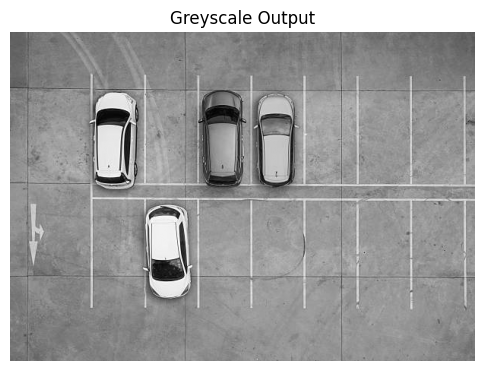

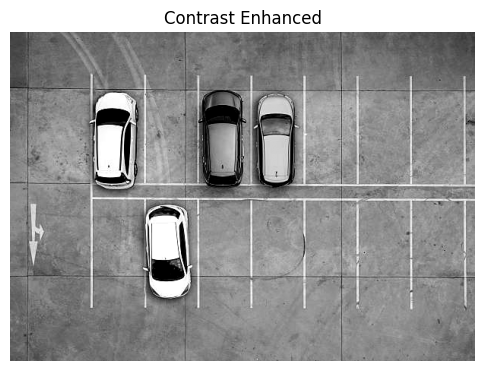

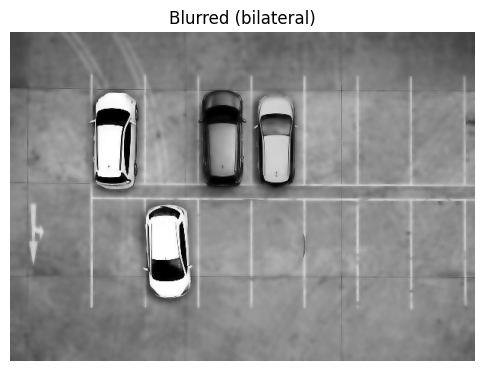

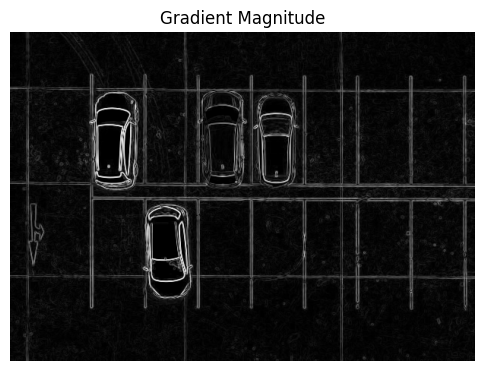

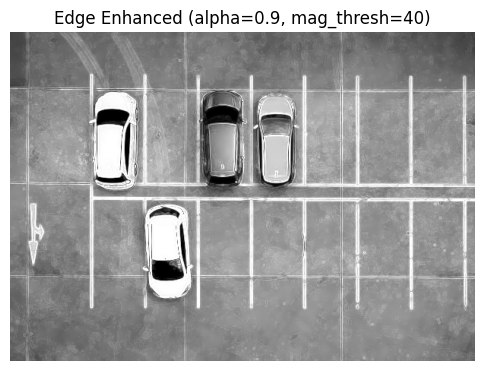

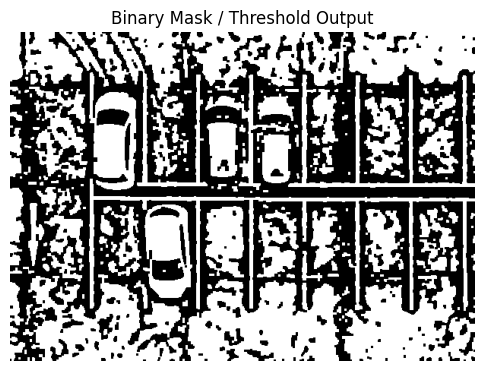

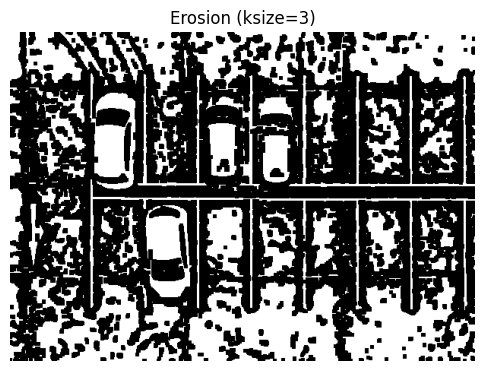

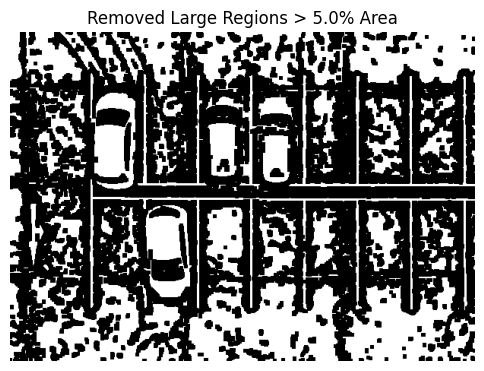

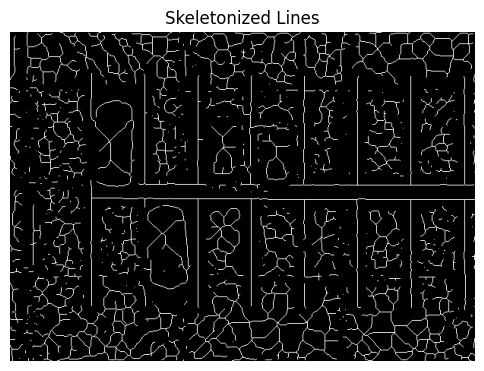

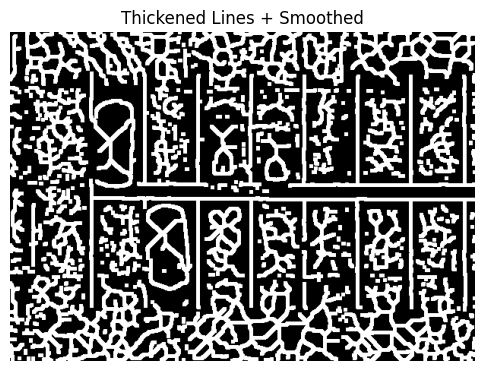

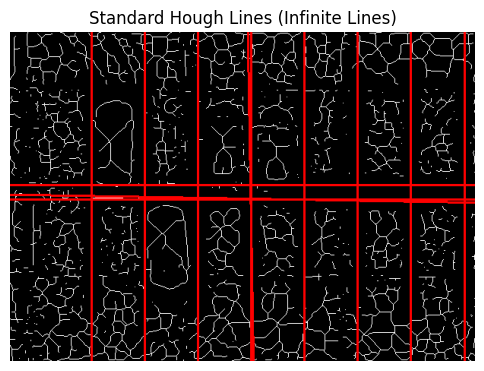

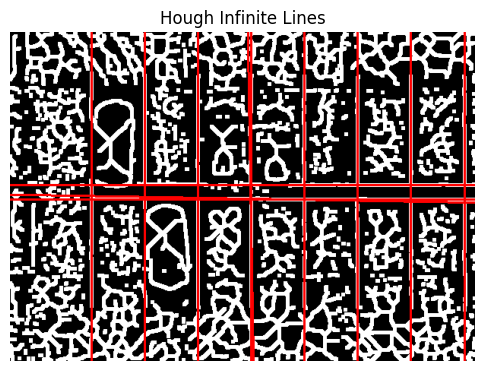

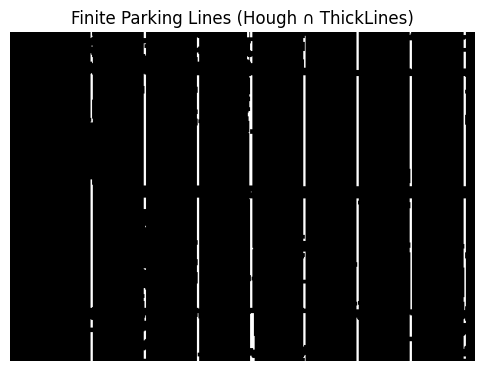

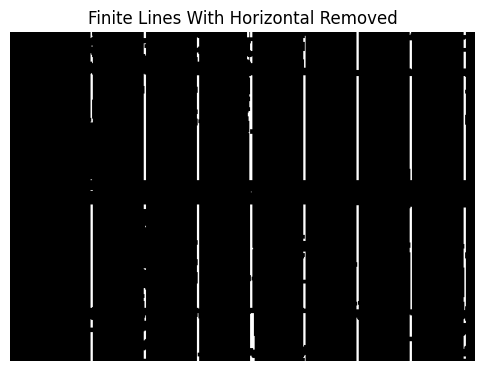

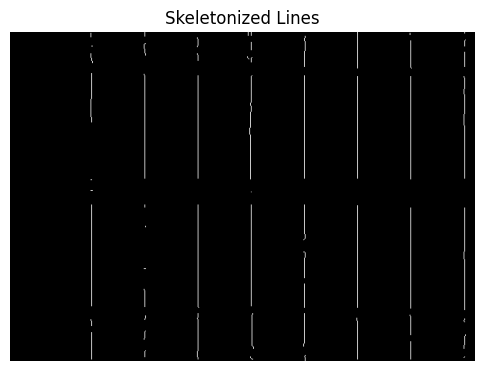

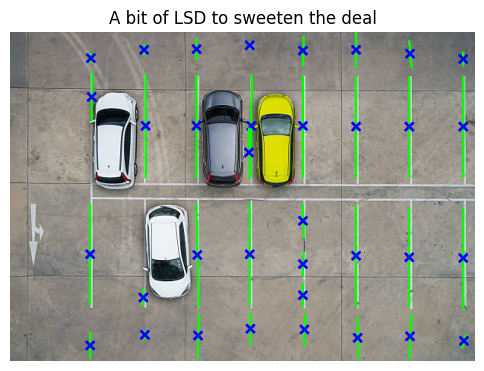

In [92]:
# --- EASY
#do_pipeline(images["easy"]["29.png"])
do_pipeline(images["easy"]["not_that_easy.jpg"])
#do_pipeline(images["easy"]["easy.jpg"])
#do_pipeline(images["easy"]["20.png"])

# --- Medium 
#do_pipeline(images["medium"]["12.png"])
#do_pipeline(images["medium"]["30.png"])
#do_pipeline(images["medium"]["31.png"])

# -- Hard
#do_pipeline(images["hard"]["frame600.jpg"])
#do_pipeline(images["hard"]["frame1.jpg"])
#do_pipeline(images["hard"]["21.png"])
